In [43]:
import pandas as pd
df = pd.read_csv("../data/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,...,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,...,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",...,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",...,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,...,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",...,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [44]:
df.shape

(8807, 12)

In [45]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [46]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [47]:
df = df.dropna(subset=['country'])

In [48]:
df['type'].value_counts()

type
Movie      5691
TV Show    2285
Name: count, dtype: int64

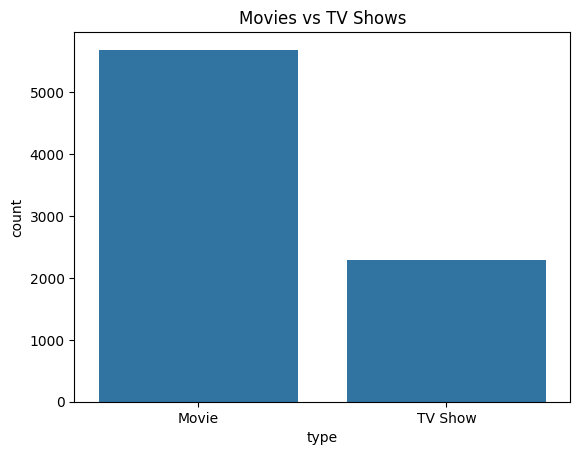

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

In [53]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

df = df.dropna(subset=['year_added'])

In [54]:
df['year_added'].value_counts().sort_index()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      79
2016.0     410
2017.0    1123
2018.0    1530
2019.0    1858
2020.0    1771
2021.0    1140
Name: count, dtype: int64

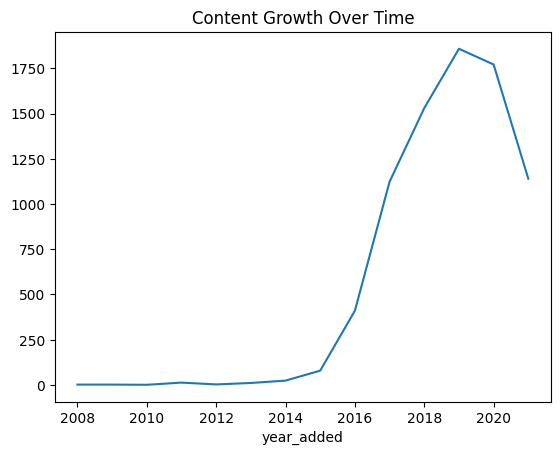

In [55]:
df['year_added'].value_counts().sort_index().plot()
plt.title("Content Growth Over Time")
plt.show()

In [56]:
df['country'].value_counts().head(10)

country
United States     2812
India              972
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

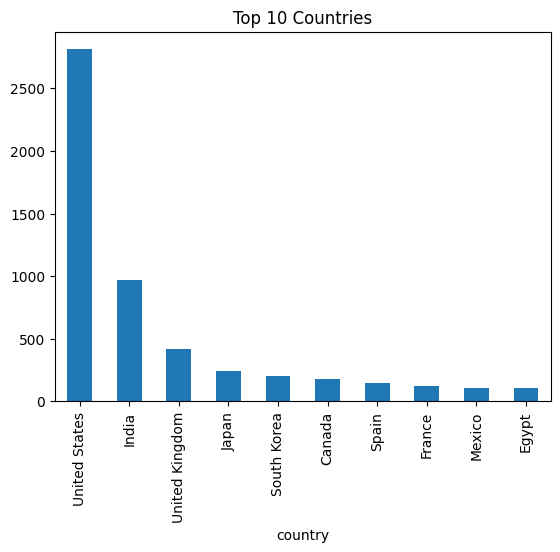

In [57]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()

In [58]:
df['listed_in'].str.split(',').explode().value_counts().head(10)

listed_in
 International Movies     2429
Dramas                    1528
Comedies                  1148
Action & Adventure         817
 Dramas                    789
Documentaries              759
 Independent Movies        725
International TV Shows     614
 TV Dramas                 597
 Romantic Movies           585
Name: count, dtype: int64

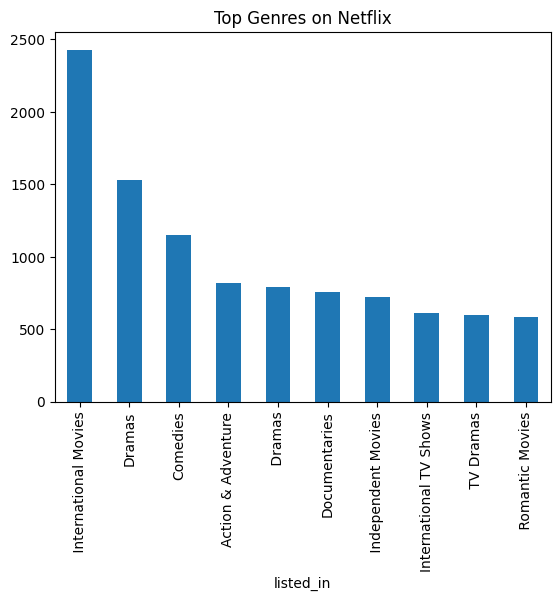

In [59]:
df['listed_in'].str.split(',').explode().value_counts().head(10).plot(kind='bar')
plt.title("Top Genres on Netflix")
plt.show()